<a href="https://colab.research.google.com/github/chavezgranados/Quantitative-Methods/blob/main/notebooks/cuaderno4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">

<font face="gotham" color="#1B5E20"> Unidad de Posgrado de la Facultad de Economía </font>

<img src="https://yachay.digital/wp-content/uploads/2021/03/uncp.png" width="120">

<font face="gotham" color="#1B5E20"> **Curso: Métodos Cuantitativos Aplicados a la Investigación** </font>

<hr width="50%" color="#C9A227">

<font face="gotham" color="#1B5E20"> Maestría en Planificación y Proyectos de Inversión </font>

<font face="gotham" color="#1B5E20"> `Luis Chávez` </font>

<font face="gotham" color="#1B5E20"> 2026 </font>

# <font face="gotham" color="#E3B10D"> **Tópico: reducción de datos**

In [ ]:
# Preámbulo ====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
url="https://raw.githubusercontent.com/chavezgranados/Quantitative-Methods/refs/heads/main/datasets/02housing.csv"
datos=pd.read_csv(url)
datos

,Unnamed: 0,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


Detalles de la base se encuentra en:
https://github.com/wblakecannon/ames/tree/master

## **1. Selección de variables**

In [ ]:
datos1 = datos.drop(columns=["Unnamed: 0", "Order", "PID"])
datos1

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,AllPub,CulDSac,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,20,RL,NaN,8885,Pave,NaN,IR1,Low,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


In [ ]:
faltantes = datos1.isna().mean() * 100
vars_eliminar = faltantes[faltantes > 40].index
datos2 = datos1.drop(columns=vars_eliminar)

In [ ]:
print(datos1.shape)
print(datos2.shape)

(2930, 80)
(2930, 74)


## **2. Selección de instancias**

In [ ]:
muestra = datos2.sample(frac=0.10, random_state=123)

In [ ]:
muestra.shape

(293, 74)

In [ ]:
datos = datos.drop_duplicates()

In [ ]:
X = datos2[["Gr Liv Area", "Overall Qual", "SalePrice"]]

kmeans = KMeans(n_clusters=500, random_state=123)
datos2["cluster"] = kmeans.fit_predict(X)

representantes = (datos2.groupby("cluster").sample(n=1, random_state=123))

In [ ]:
representantes

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,...,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice,cluster
693,50,RM,68.0,4080,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,6,2009,WD,Normal,128900,0
563,20,RL,NaN,15676,Pave,IR1,Low,AllPub,Inside,Gtl,...,255,0,0,0,4,2009,WD,Normal,275000,1
968,20,RL,85.0,12633,Pave,IR1,HLS,AllPub,Inside,Gtl,...,0,0,0,0,5,2009,WD,Normal,425000,2
2101,20,RL,103.0,11175,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,10,2007,New,Partial,200141,3
941,70,RM,60.0,6402,Pave,Reg,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,7,2009,WD,Normal,78000,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023,50,RL,60.0,8850,Pave,Reg,Bnk,AllPub,Inside,Gtl,...,0,0,0,0,2,2007,WD,Normal,165000,495
499,60,RL,79.0,10208,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,7,2009,WD,Normal,265000,496
892,180,RM,35.0,3675,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,4,2009,WD,Normal,145500,497
2522,20,RL,68.0,50271,Pave,IR1,Low,AllPub,Inside,Gtl,...,0,0,0,0,11,2006,WD,Normal,385000,498


## **3. Reducción de dimensionalidad**

In [ ]:
X = datos2.select_dtypes(include="number")

print(X.shape)

(2930, 38)


In [ ]:
X.isnull().sum().sort_values(ascending=False)

,0
Lot Frontage,490
Garage Yr Blt,159
Mas Vnr Area,23
Bsmt Full Bath,2
Bsmt Half Bath,2
Total Bsmt SF,1
Garage Cars,1
Garage Area,1
BsmtFin SF 2,1
BsmtFin SF 1,1


In [ ]:
X = X.fillna(X.mean())

In [ ]:
# Estandarizar variables
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

In [ ]:
pca = PCA()
pca.fit(X_std)

PCA()

In [ ]:
# Varianza explicada
pca.explained_variance_ratio_

array([0.21024056, 0.08523713, 0.06705353, 0.0527495 , 0.03865226,
       0.03132349, 0.03062995, 0.03042074, 0.02941034, 0.02847086,
       0.02815401, 0.02685271, 0.02590928, 0.02551411, 0.02476638,
       0.02429056, 0.02346991, 0.02252058, 0.02139744, 0.02017612,
       0.01856667, 0.0174791 , 0.01622882, 0.01491742, 0.01452726,
       0.01137327, 0.00998121, 0.00876314, 0.00788073, 0.0075176 ,
       0.00646766, 0.00567718, 0.00413277, 0.00376966, 0.00308655,
       0.00239151, 0.        , 0.        ])

In [ ]:
# Varianza explicada acumulada
var_acum = np.cumsum(pca.explained_variance_ratio_)
print(var_acum)

[0.21024056 0.29547769 0.36253122 0.41528072 0.45393298 0.48525648
 0.51588643 0.54630717 0.5757175  0.60418837 0.63234237 0.65919509
 0.68510436 0.71061847 0.73538485 0.75967541 0.78314532 0.8056659
 0.82706334 0.84723945 0.86580612 0.88328522 0.89951405 0.91443147
 0.92895873 0.940332   0.95031321 0.95907635 0.96695708 0.97447468
 0.98094234 0.98661951 0.99075228 0.99452194 0.99760849 1.
 1.         1.        ]


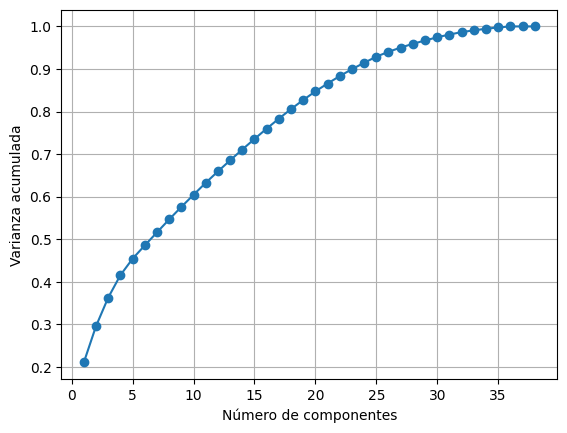

In [ ]:
# Selección del número de componentes
plt.plot(range(1, len(var_acum)+1),
    var_acum, marker="o")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.grid(True)
plt.show()

In [ ]:
pca = PCA(n_components=15)
X_reducido = pca.fit_transform(X_std)

In [ ]:
X_reducido.shape

(2930, 15)

In [ ]:
X_reducido = pd.DataFrame(X_reducido,columns=[f"PC{i}" for i in range(1, 16)])
X_reducido

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15
0,1.379824,-1.420835,-3.768832,-0.137893,-0.133253,1.838946,-0.030729,-1.724106,-0.635623,0.297624,-0.143484,-0.451309,-0.208795,1.498057,0.752101
1,-2.541834,-1.710374,-0.714264,0.174568,-0.775474,0.994628,0.642351,-0.470038,-1.094462,-0.986055,-0.473192,0.506213,0.816659,-0.536519,0.210544
2,-0.442276,-1.075995,-3.162872,-0.930368,0.215948,-0.220152,-4.490112,3.685851,-6.432590,0.098174,15.595499,1.427427,-5.007936,3.919619,2.881367
3,3.008281,-0.822072,-2.403466,0.649013,0.873721,1.692163,-0.095250,0.411698,-0.097429,-1.031533,-0.486142,-0.519609,-0.254538,1.379031,0.287997
4,0.787231,0.550785,1.081438,-1.334095,-0.275768,1.713046,-0.900401,-1.315769,-0.423775,-0.427994,0.273465,-0.380145,0.322001,0.822482,0.582194
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,-1.137369,-1.666735,1.117752,-0.743774,0.798167,-0.044000,0.034775,0.108457,0.268100,0.411745,0.046418,-0.058611,-0.200908,-1.319374,0.296503
2926,-1.777897,-2.161190,0.546429,-0.163095,-0.039068,-0.633819,0.019090,-2.034367,0.360204,0.708419,-0.342089,0.857024,-0.405652,0.436468,-0.030206
2927,-2.793469,-0.359753,0.478879,0.446913,-0.235533,-3.008190,-1.515901,-0.168065,-0.954838,-1.000721,2.159408,-0.526568,0.771656,-0.248387,0.634474
2928,-0.196041,-2.469174,-1.073009,-0.686138,0.458968,-0.334955,-0.214432,-1.062812,0.614814,0.501078,0.046555,-0.043970,-0.750155,1.377382,0.256085


## **4. Agregación**

In [ ]:
conteo = (datos2.groupby("Neighborhood").size().reset_index(name="Cantidad"))
conteo.head()

,Neighborhood,Cantidad
0,Blmngtn,28
1,Blueste,10
2,BrDale,30
3,BrkSide,108
4,ClearCr,44


In [ ]:
precio_barrio = (datos.groupby("Neighborhood")["SalePrice"].mean().reset_index())
precio_barrio.head()

,Neighborhood,SalePrice
0,Blmngtn,196661.678571
1,Blueste,143590.000000
2,BrDale,105608.333333
3,BrkSide,124756.250000
4,ClearCr,208662.090909
